# 02 — Modélisation

Pipeline complet de modélisation :
1. Chargement et prétraitement
2. Baseline
3. Régression Logistique
4. Random Forest
5. XGBoost
6. Comparaison des modèles

> ⚠️ L'attribut `duration` est **exclu** des modèles (car inconnu avant la fin de l'appel).

In [1]:
import pandas as pd
import numpy as np
import sys
sys.path.insert(0, '..')

from src.data_loader import load_bank, load_bank_additional
from src.preprocessing import (
    separate_features_target,
    get_column_types,
    split_data,
    build_preprocessing_pipeline,
)
from src.modeling import (
    get_baseline,
    get_logistic_regression,
    get_random_forest,
    get_xgboost,
    tune_model,
)
from src.evaluation import (
    get_metrics,
    print_classification_report,
    plot_confusion_matrix,
    plot_roc_curve,
    plot_feature_importance,
    compare_models,
)
from src.utils import set_seed, Timer, save_model

set_seed(42)
%matplotlib inline

## 1. Chargement des données

In [2]:
# Choisir le dataset à utiliser
# Option 1 : Bank (UCI original)
df = load_bank(full=True)

# Option 2 : Bank Additional (enrichi)
# df = load_bank_additional(full=True)

print(f"Shape: {df.shape}")

Shape: (45211, 17)


## 2. Séparation features / target

In [3]:
X, y = separate_features_target(df, drop_duration=True)
print(f"X: {X.shape}, y: {y.shape}")
print(f"Class distribution:\n{y.value_counts()}")

X: (45211, 15), y: (45211,)
Class distribution:
y
0    39922
1     5289
Name: count, dtype: int64


## 3. Train / Test split

In [4]:
X_train, X_test, y_train, y_test = split_data(X, y, test_size=0.2, stratify=True)

## 4. Prétraitement

In [5]:
num_cols, cat_cols = get_column_types(X_train)
print(f"Numerical columns ({len(num_cols)}): {num_cols}")
print(f"Categorical columns ({len(cat_cols)}): {cat_cols}")

preprocessor = build_preprocessing_pipeline(num_cols, cat_cols)
X_train_pp = preprocessor.fit_transform(X_train)
X_test_pp = preprocessor.transform(X_test)

print(f"X_train after preprocessing: {X_train_pp.shape}")

Numerical columns (6): ['age', 'balance', 'day', 'campaign', 'pdays', 'previous']
Categorical columns (9): ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']
X_train after preprocessing: (36168, 41)


## 5. Modèle baseline

In [6]:
baseline = get_baseline(strategy='stratified')
baseline.fit(X_train_pp, y_train)
y_pred_base = baseline.predict(X_test_pp)
print("Baseline (stratified):")
print(get_metrics(y_test, y_pred_base))

Baseline (stratified):
{'Accuracy': 0.7959747871281654, 'Precision': 0.11154985192497532, 'Recall': 0.10680529300567108, 'F1-Score': 0.10912602607436021}


## 6. Régression Logistique

In [7]:
lr = get_logistic_regression(class_weight='balanced', max_iter=2000)
with Timer("Logistic Regression"):
    lr.fit(X_train_pp, y_train)
y_pred_lr = lr.predict(X_test_pp)
y_proba_lr = lr.predict_proba(X_test_pp)[:, 1]
print_classification_report(y_test, y_pred_lr)

[Logistic Regression] 132 ms
              precision    recall  f1-score   support

      No (0)       0.94      0.77      0.85      7985
     Yes (1)       0.27      0.62      0.37      1058

    accuracy                           0.76      9043
   macro avg       0.60      0.70      0.61      9043
weighted avg       0.86      0.76      0.79      9043



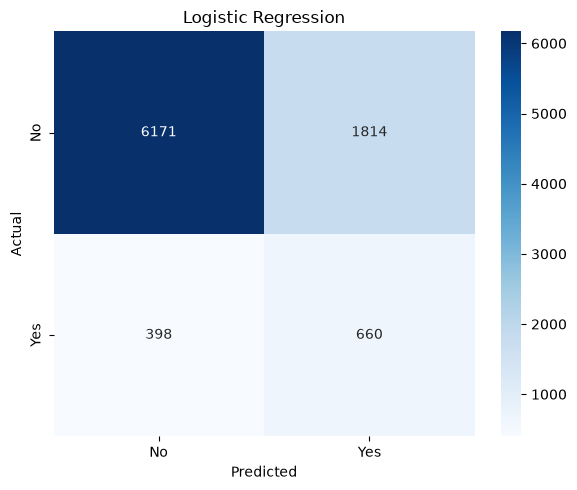

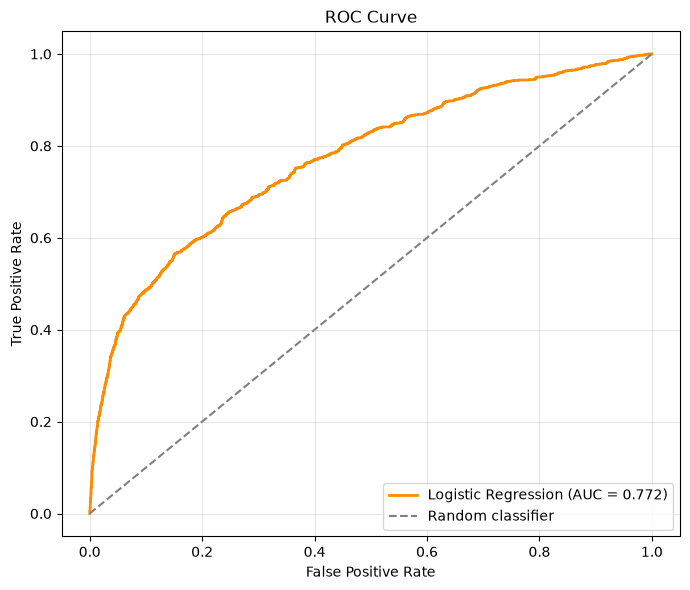

In [8]:
plot_confusion_matrix(y_test, y_pred_lr, title='Logistic Regression')
plot_roc_curve(y_test, y_proba_lr, label='Logistic Regression')

## 7. Random Forest

In [9]:
rf = get_random_forest(n_estimators=200, class_weight='balanced')
with Timer("Random Forest"):
    rf.fit(X_train_pp, y_train)
y_pred_rf = rf.predict(X_test_pp)
y_proba_rf = rf.predict_proba(X_test_pp)[:, 1]
print_classification_report(y_test, y_pred_rf)

[Random Forest] 2.54 s
              precision    recall  f1-score   support

      No (0)       0.92      0.94      0.93      7985
     Yes (1)       0.49      0.40      0.44      1058

    accuracy                           0.88      9043
   macro avg       0.71      0.67      0.69      9043
weighted avg       0.87      0.88      0.88      9043



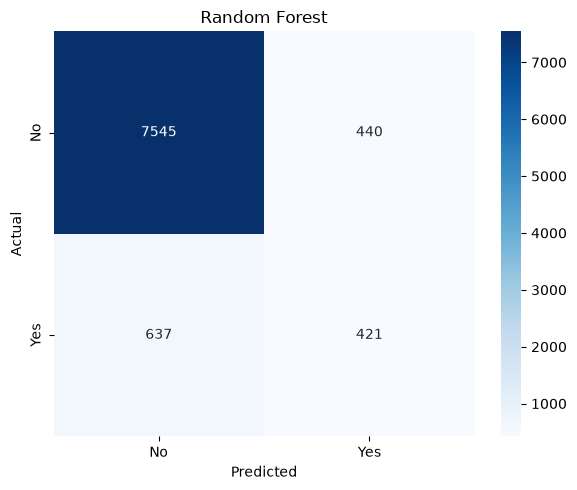

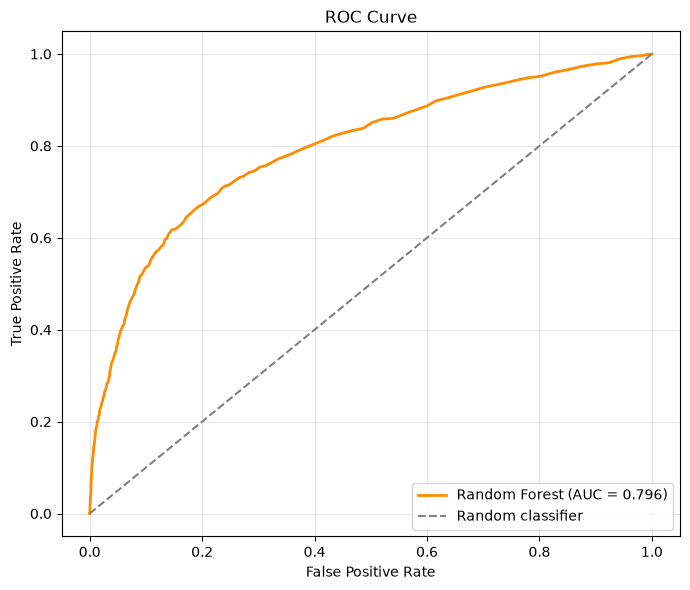

c:\Users\Manon\Documents\bank-marketing\notebooks\..\src\evaluation.py:134: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance_df, x="importance", y="feature", palette="viridis", ax=ax)


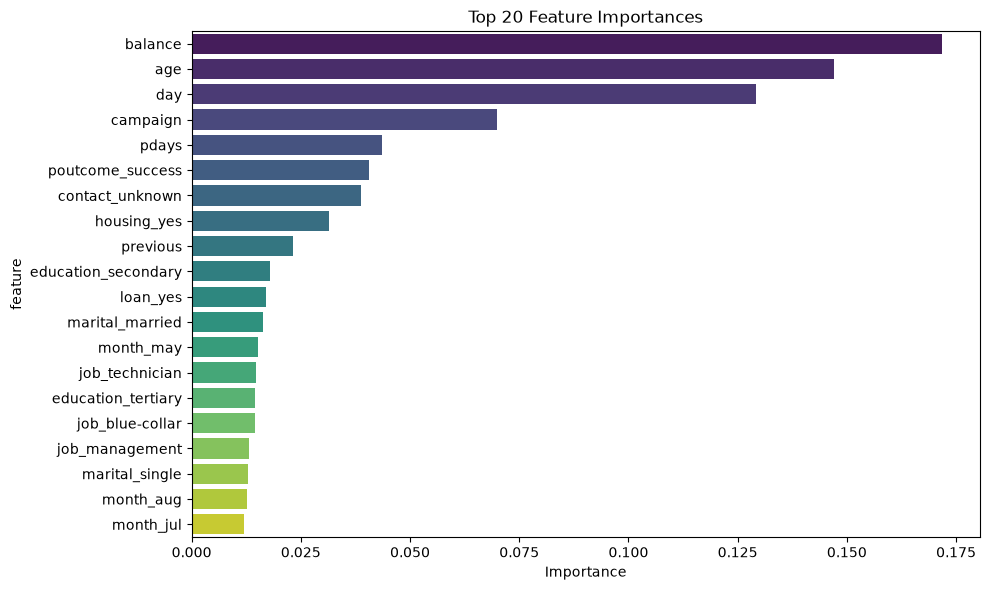

In [10]:
plot_confusion_matrix(y_test, y_pred_rf, title='Random Forest')
plot_roc_curve(y_test, y_proba_rf, label='Random Forest')
# Feature importance
plot_feature_importance(rf, num_cols + list(preprocessor.named_transformers_['cat'].get_feature_names_out(cat_cols)))

## 8. XGBoost

In [11]:
neg, pos = np.bincount(y_train)
scale_pos_weight = neg / pos
xgb = get_xgboost(scale_pos_weight=scale_pos_weight, n_estimators=200)
with Timer("XGBoost"):
    xgb.fit(X_train_pp, y_train)
y_pred_xgb = xgb.predict(X_test_pp)
y_proba_xgb = xgb.predict_proba(X_test_pp)[:, 1]
print_classification_report(y_test, y_pred_xgb)

c:\Users\Manon\Documents\bank-marketing\venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [13:29:40] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[XGBoost] 760 ms
              precision    recall  f1-score   support

      No (0)       0.94      0.85      0.90      7985
     Yes (1)       0.36      0.62      0.46      1058

    accuracy                           0.83      9043
   macro avg       0.65      0.74      0.68      9043
weighted avg       0.88      0.83      0.84      9043



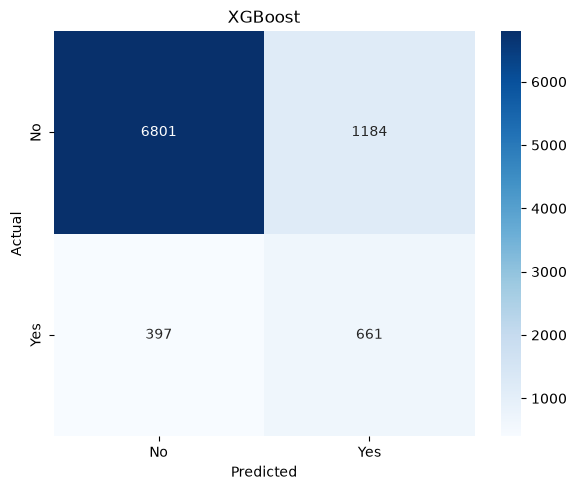

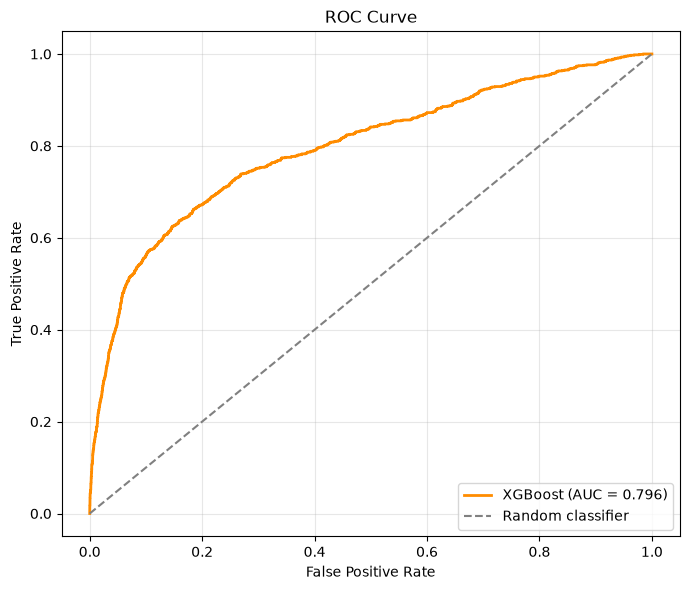

c:\Users\Manon\Documents\bank-marketing\notebooks\..\src\evaluation.py:134: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance_df, x="importance", y="feature", palette="viridis", ax=ax)


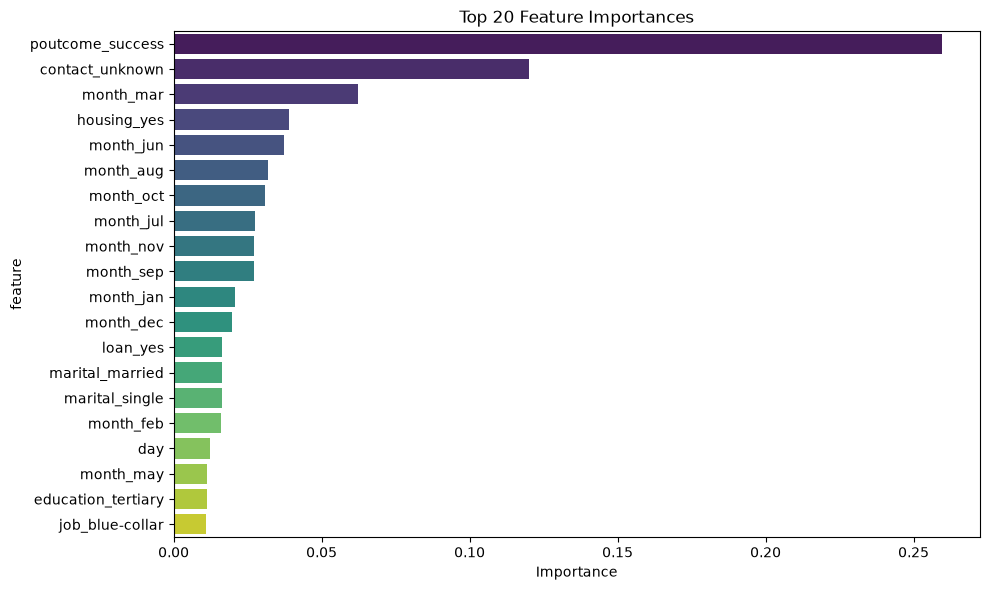

In [12]:
plot_confusion_matrix(y_test, y_pred_xgb, title='XGBoost')
plot_roc_curve(y_test, y_proba_xgb, label='XGBoost')
plot_feature_importance(xgb, num_cols + list(preprocessor.named_transformers_['cat'].get_feature_names_out(cat_cols)))

## 9. Comparaison des modèles

In [13]:
results = {
    "Baseline": get_metrics(y_test, y_pred_base),
    "Logistic Regression": get_metrics(y_test, y_pred_lr, y_proba_lr),
    "Random Forest": get_metrics(y_test, y_pred_rf, y_proba_rf),
    "XGBoost": get_metrics(y_test, y_pred_xgb, y_proba_xgb),
}
compare_models(results, sort_by="ROC-AUC")

,Accuracy,Precision,Recall,F1-Score,ROC-AUC
XGBoost,0.825169,0.358266,0.624764,0.455391,0.796042
Random Forest,0.880902,0.488966,0.397921,0.438770,0.795772
Logistic Regression,0.755391,0.266774,0.623819,0.373726,0.772105
Baseline,0.795975,0.111550,0.106805,0.109126,NaN


## 10. Sauvegarde du meilleur modèle

In [14]:
# save_model(rf, 'random_forest_bank')